In [1]:
import pandas as pd
import numpy as np

meta = pd.read_csv("../data/raw/proteomic/all_subtypes.v5.1.tsv",sep = '\t')
meta['rna_wang_cancer_cell_2017'].unique()
tumor_id = meta[meta["sample_type"] == "tumor"]["case"].tolist()
proneural_id = meta[meta['rna_wang_cancer_cell_2017'] == 'Proneural']['case'].tolist()
mesenchymal_id = meta[meta['rna_wang_cancer_cell_2017'] == 'Mesenchymal']['case'].tolist()
classical_id = meta[meta['rna_wang_cancer_cell_2017'] == 'Classical']['case'].tolist()
idh_id = meta[meta['rna_wang_cancer_cell_2017'] == 'IDH mutant']['case'].tolist()
normal_id = meta[meta["sample_type"] == "GTEx normal"]["case"].tolist()
normal_id.pop(2)

'PT-Q2AG'

In [2]:

rna = pd.read_csv(
    "../data/raw/Gene_Expression_RNA/rnaseq_washu_fpkm_uq.v4.0.tsv.gz",
    sep="\t"
)
rna = rna.drop(['gene_id','gene_type','gene_status','havana_gene','full_length','exon_length','exon_num'],axis=1).set_index('gene_name')
print(rna.shape)
rna = np.log2(rna + 1)

pro = pd.read_csv("../data/interim/de_proteome.csv").set_index("gene")
proset = set(pro.index)
rnaset = set(rna.index)

common = list(proset & rnaset)
print(common)
print(len(common))

rna = rna.T
rna = rna[common]
rna = rna.T

(60483, 108)
['FAM221A', 'FGB', 'CCDC71L', 'NUDT2', 'RPL13A', 'ZNF346', 'ZNF655', 'MECR', 'ZNF711', 'SLC7A1', 'DNTTIP1', 'GARS', 'LINGO1', 'SCAF11', 'HBA2', 'PLLP', 'NPNT', 'GSTA4', 'LARS2', 'PCYOX1L', 'RTF1', 'POLR3C', 'TMEM104', 'NHS', 'SOX10', 'KCNJ6', 'DES', 'GSPT2', 'MMAA', 'CDS2', 'PSMB1', 'A1BG', 'PRDX6', 'SLC39A7', 'IDI1', 'UQCRH', 'S100A13', 'TBC1D12', 'FAM76B', 'IKZF1', 'C7', 'TM6SF1', 'CXorf36', 'TINAGL1', 'SEPT1', 'COG6', 'LLGL1', 'CUTA', 'TJAP1', 'FAM213A', 'NUPR1', 'ITGA7', 'PEX5L', 'NEU1', 'PMM2', 'TAGLN3', 'STX1B', 'SH3RF3', 'WWC3', 'RPS25', 'CXXC1', 'EPHA7', 'HNRNPA3', 'RALBP1', 'BCL2L13', 'MRPL18', 'PRPH', 'ANTXR2', 'ICA1L', 'NOL8', 'ZBED8', 'CD5L', 'PPP1R1B', 'GLE1', 'GNLY', 'CENPK', 'SNTA1', 'AHSP', 'DHFR', 'RBM42', 'PLA2G15', 'IFNGR1', 'RAB5A', 'DHPS', 'CALB1', 'TRIM9', 'CYC1', 'SLC41A3', 'TKTL2', 'WDR11', 'HMGN4', 'RRBP1', 'RSBN1', 'LHFPL4', 'LONP1', 'RAB35', 'TSC22D4', 'C7orf43', 'PIR', 'SLC1A2', 'RECQL5', 'YAF2', 'PTP4A2', 'RWDD2B', 'GREM1', 'ZNF512', 'PPFIA2', 

In [3]:
gbm_expr = rna[tumor_id]
proneural_expr = rna[proneural_id]
mesenchymal_expr = rna[mesenchymal_id]
classical_expr = rna[classical_id]
idh_expr = rna[idh_id]
normal_expr = rna[normal_id]
normal_expr

,PT-NPJ7,PT-P44H,PT-QVJO,PT-R55F,PT-RN5K,PT-RU72,PT-UTHO,PT-WVLH,PT-Y8DK
gene_name,,,,,,,,,
FAM221A,14.745268,15.295610,15.143888,14.990722,14.709253,14.885124,15.934840,14.450030,14.697753
FGB,0.000000,0.000000,0.000000,0.000000,7.730486,0.000000,0.000000,0.000000,0.000000
CCDC71L,15.127846,15.617525,15.213172,15.481930,15.369618,15.339991,15.010621,15.792583,15.593931
NUDT2,18.174388,18.068301,17.930850,17.865306,16.987316,17.882164,17.733982,18.451580,18.136203
RPL13A,21.152269,21.281449,20.966838,21.036688,21.261478,21.015236,20.774106,21.152265,21.077343
...,...,...,...,...,...,...,...,...,...
MED14,16.330869,16.580357,16.532161,16.282108,16.453645,16.372279,16.641312,16.164098,16.198901
USP53,16.476159,16.219452,16.706149,16.448047,16.892591,16.440362,15.973149,16.108638,16.051684
MTSS1L,19.424642,19.626015,19.813702,19.924710,21.073559,19.927027,19.814912,19.866373,20.241053


In [4]:
print(proneural_expr.shape)
print(mesenchymal_expr.shape)
print(classical_expr.shape)

print(proneural_expr.columns[:5])
print(mesenchymal_expr.columns[:5])
print(classical_expr.columns[:5])

(10121, 29)
(10121, 39)
(10121, 25)
Index(['C3L-00104', 'C3L-00677', 'C3L-01146', 'C3L-01149', 'C3L-01157'], dtype='str')
Index(['C3L-00674', 'C3L-01043', 'C3L-01045', 'C3L-01046', 'C3L-01049'], dtype='str')
Index(['C3L-00365', 'C3L-01040', 'C3L-01048', 'C3L-01061', 'C3L-01154'], dtype='str')


In [6]:
def keep_highest_max_duplicate(df):
    return (
        df.assign(_max=df.max(axis=1))
          .sort_values("_max", ascending=False)
          .groupby(level=0)
          .first()
          .drop(columns="_max")
    )

datasets = {
    'gbm': gbm_expr,
    "proneural": proneural_expr,
    "mesenchymal": mesenchymal_expr,
    "classical": classical_expr,
    "idh": idh_expr,
    "normal": normal_expr
}

datasets = {
    name: keep_highest_max_duplicate(df)
    for name, df in datasets.items()
}

gbm_expr = datasets['gbm']
proneural_expr = datasets["proneural"]
mesenchymal_expr = datasets["mesenchymal"]
classical_expr = datasets["classical"]
idh_expr = datasets["idh"]
normal_expr = datasets["normal"]

# Import diffential analysis module

In [11]:
import sys
sys.path.append("../src")

import diff
import importlib

importlib.reload(diff)


<module 'diff' from 'c:\\Users\\haina\\Desktop\\BIO_RA\\notebooks\\../src\\diff.py'>

# Entire dataset

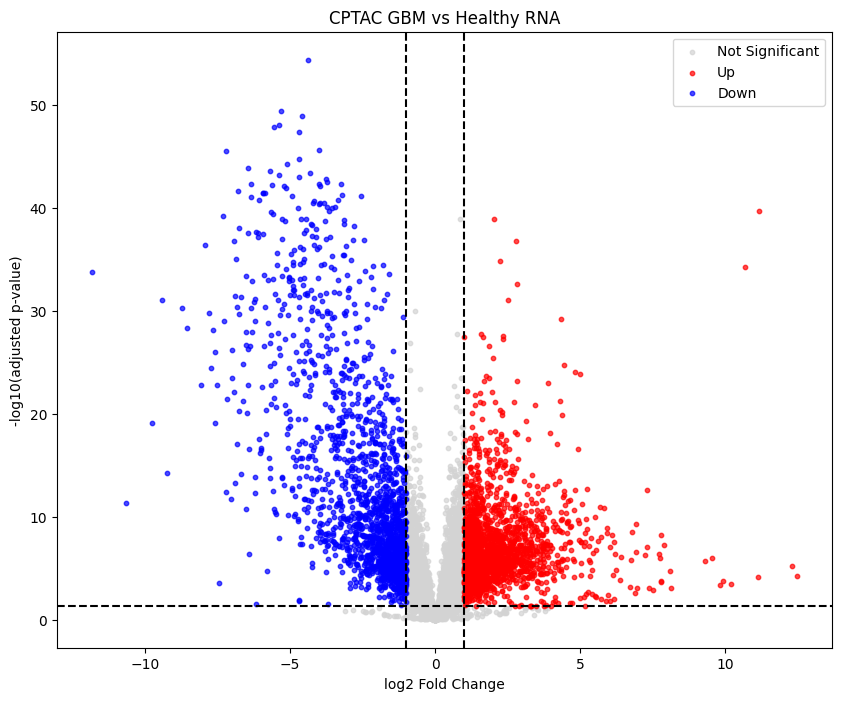

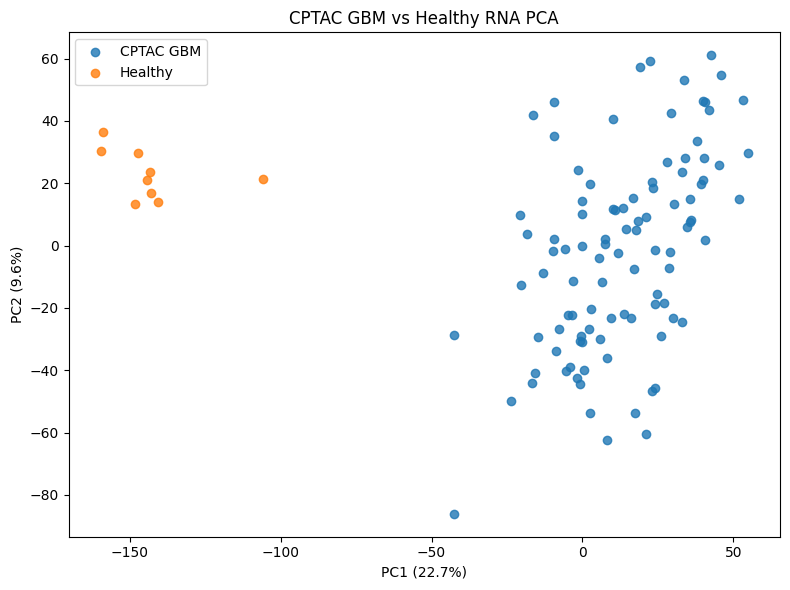

In [12]:
gbm = diff.differential_expression(gbm_expr,normal_expr)
diff.volcano_plot(gbm,'CPTAC GBM vs Healthy RNA')
diff.pca_plot(gbm_expr,normal_expr,'CPTAC GBM','Healthy','CPTAC GBM vs Healthy RNA PCA')
gbm.to_csv('../data/interim/CPTAC_rna_diff.csv')

# Proneural 

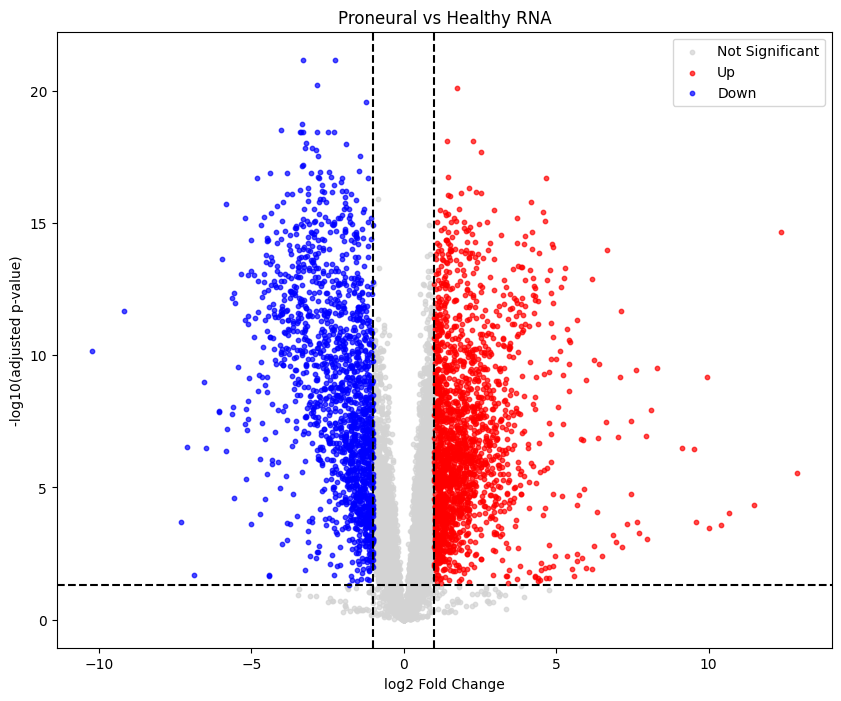

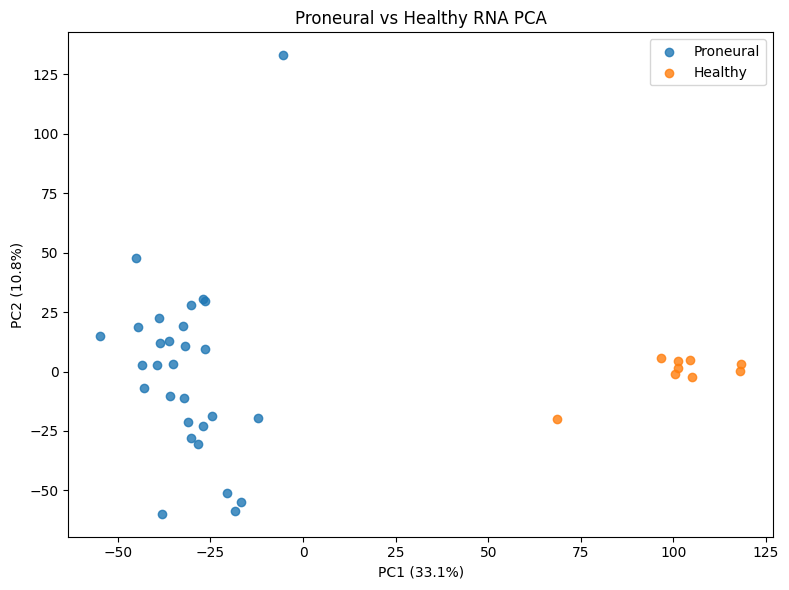

In [13]:
pro = diff.differential_expression(proneural_expr,normal_expr)
diff.volcano_plot(pro,'Proneural vs Healthy RNA')
diff.pca_plot(proneural_expr,normal_expr,'Proneural','Healthy','Proneural vs Healthy RNA PCA')
pro.to_csv('../data/interim/proneural_rna_diff.csv')

# Mesenchymal

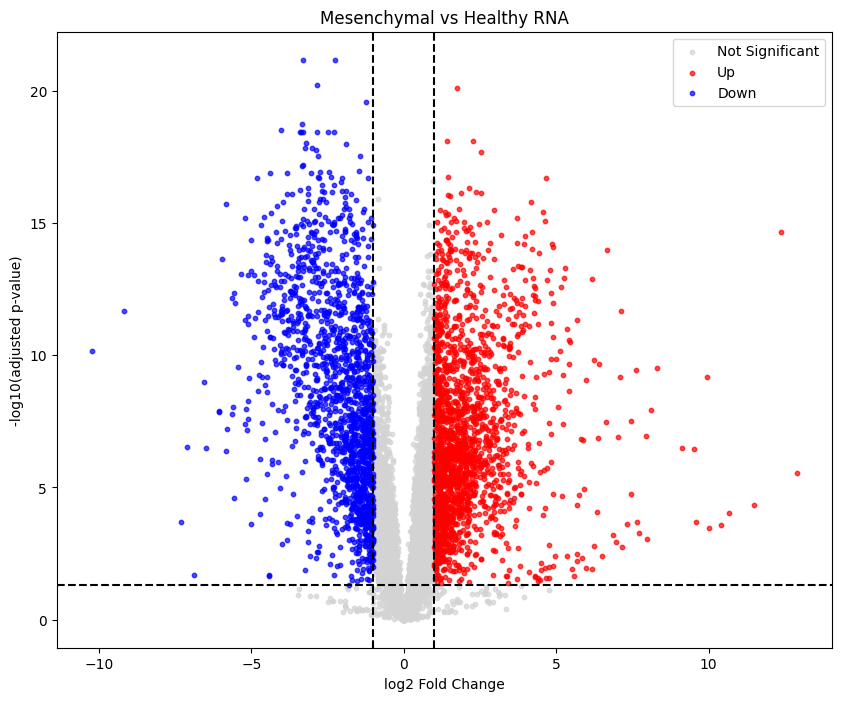

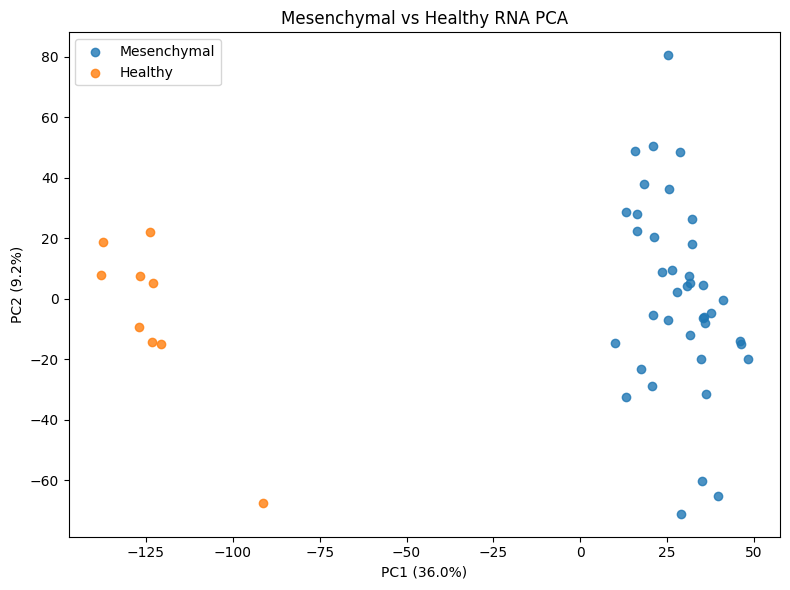

In [14]:
mes = diff.differential_expression(mesenchymal_expr,normal_expr)
diff.volcano_plot(pro,'Mesenchymal vs Healthy RNA')
diff.pca_plot(mesenchymal_expr,normal_expr,'Mesenchymal','Healthy','Mesenchymal vs Healthy RNA PCA')
mes.to_csv('../data/interim/mesenchymal_rna_diff.csv')

# Classical

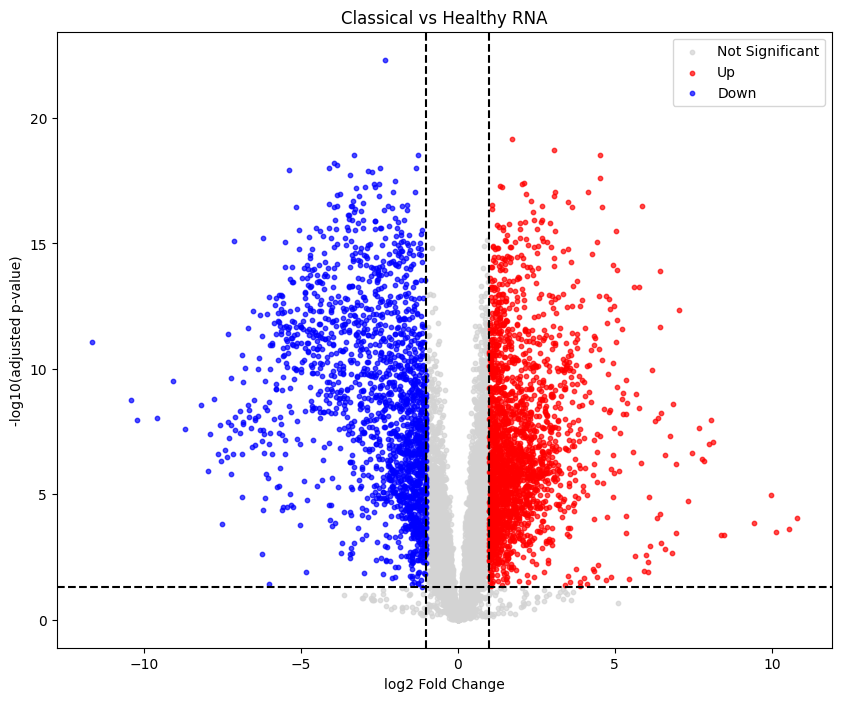

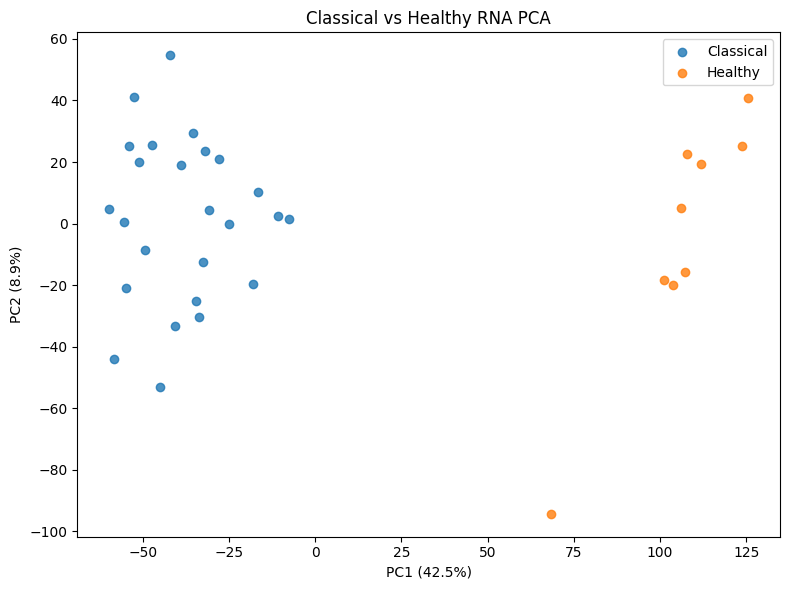

In [15]:
clas = diff.differential_expression(classical_expr,normal_expr)
diff.volcano_plot(clas,'Classical vs Healthy RNA')
diff.pca_plot(classical_expr,normal_expr,'Classical','Healthy','Classical vs Healthy RNA PCA')
clas.to_csv('../data/interim/classical_rna_diff.csv')

# IDH

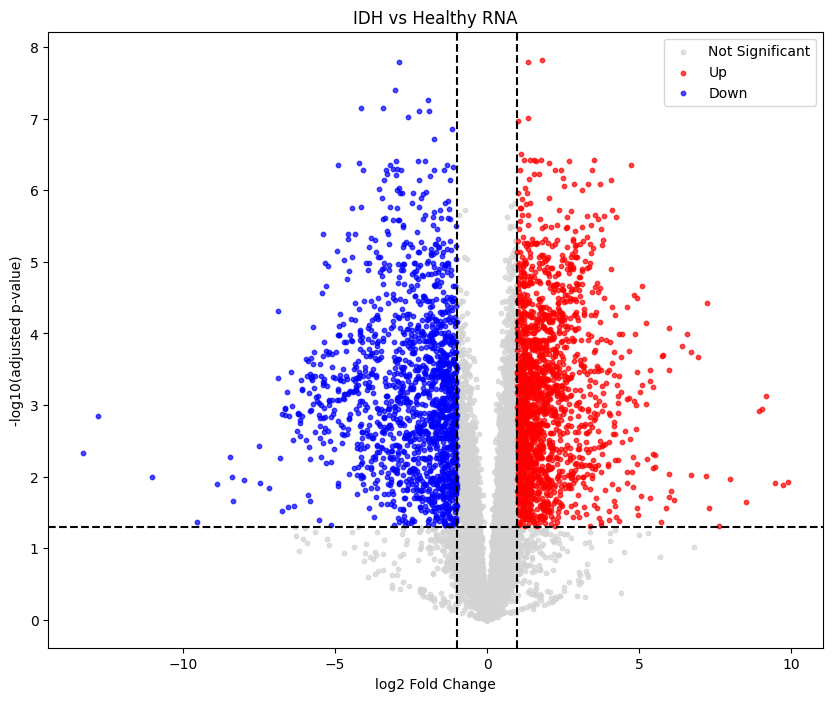

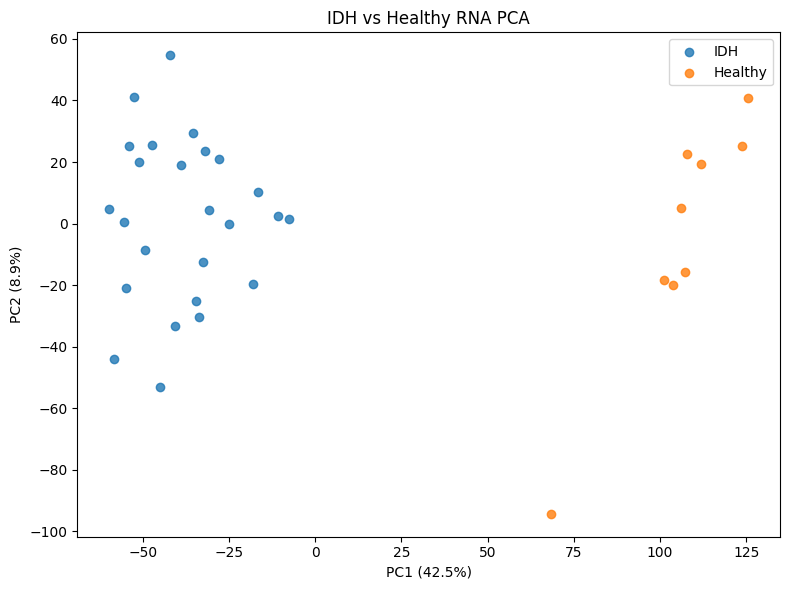

In [16]:
idh = diff.differential_expression(idh_expr,normal_expr)
diff.volcano_plot(idh,'IDH vs Healthy RNA')
diff.pca_plot(classical_expr,normal_expr,'IDH','Healthy','IDH vs Healthy RNA PCA')
idh.to_csv('../data/interim/idh_rna_diff.csv')